In [16]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

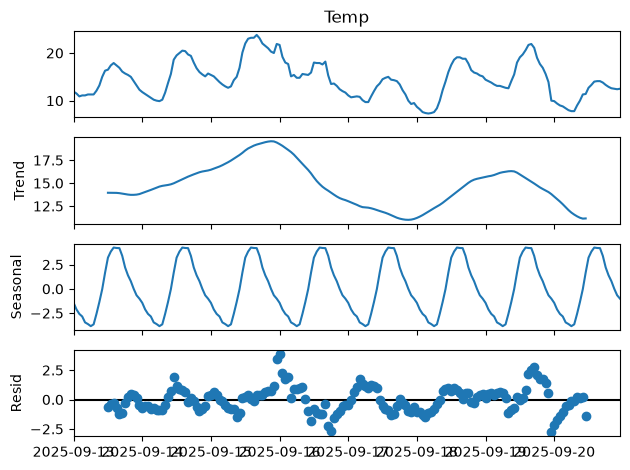

In [17]:
# Setting up for our API request
endpoint = 'https://archive-api.open-meteo.com/v1/archive'
params = {
    'latitude': -37.8136,   # Latitude for Melbourne
    'longitude': 144.9631,  # Longitude for Melbourne
    'start_date': (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d'),
    'end_date': (datetime.now() - timedelta(days=358)).strftime('%Y-%m-%d'),
    'hourly': 'temperature_2m',
    'timezone': 'Australia/Melbourne'
}

# Making request
response = requests.get(endpoint, params=params)
wdata = response.json()

# Extracting relevant data
timestamps = [datetime.fromisoformat(item) for item in wdata['hourly']['time']]
temperatures = wdata['hourly']['temperature_2m']

# Creating a pandas dataframe
wdf = pd.DataFrame({
    'Date': timestamps,
    'Temp': temperatures
})

# Setting date column as index
wdf.set_index('Date', inplace=True)

# Seasonal decomposition
decomp = seasonal_decompose(wdf['Temp'], model='additive', period=24)

# Plotting decomposed components
decomp.plot()
plt.show()

In [18]:
# ARIMA model init
arimamodel = ARIMA(wdf['Temp'], order=(1, 1, 1))
armima_fit = arimamodel.fit()

# Model summary
print(armima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                  192
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -219.509
Date:                Sun, 13 Sep 2026   AIC                            445.017
Time:                        16:37:06   BIC                            454.774
Sample:                    09-13-2025   HQIC                           448.969
                         - 09-20-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7165      0.078      9.165      0.000       0.563       0.870
ma.L1         -0.1444      0.110     -1.318      0.188      -0.359       0.070
sigma2         0.5815      0.037     15.659      0.0

/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [19]:
# Forecasting
forecast_steps = 24
forecast = armima_fit.forecast(steps=forecast_steps)
forecast_index = pd.date_range(
    start=wdf.index[-1],
    periods=forecast_steps,
    freq='h'
)

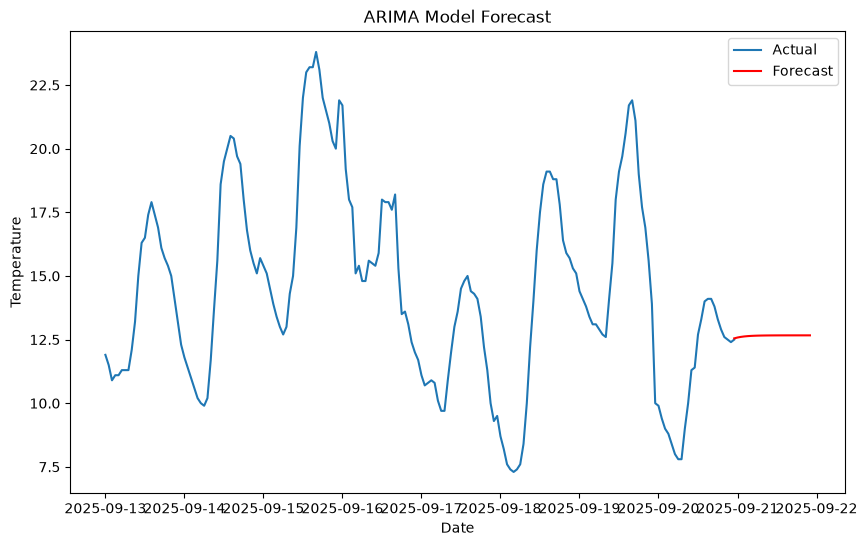

In [20]:
# Plotting the forecasts
plt.figure(figsize=(10, 6))
plt.plot(wdf['Temp'], label='Actual')
plt.plot(forecast_index, forecast, label='Forecast', color='red')
plt.title('ARIMA Model Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [21]:
# Forecast
forecast_steps = 7
forecast = armima_fit.forecast(steps=forecast_steps)
forecast_index = pd.date_range(
    start=wdf.index[-14],
    periods=forecast_steps + 1,
    inclusive='right'
)

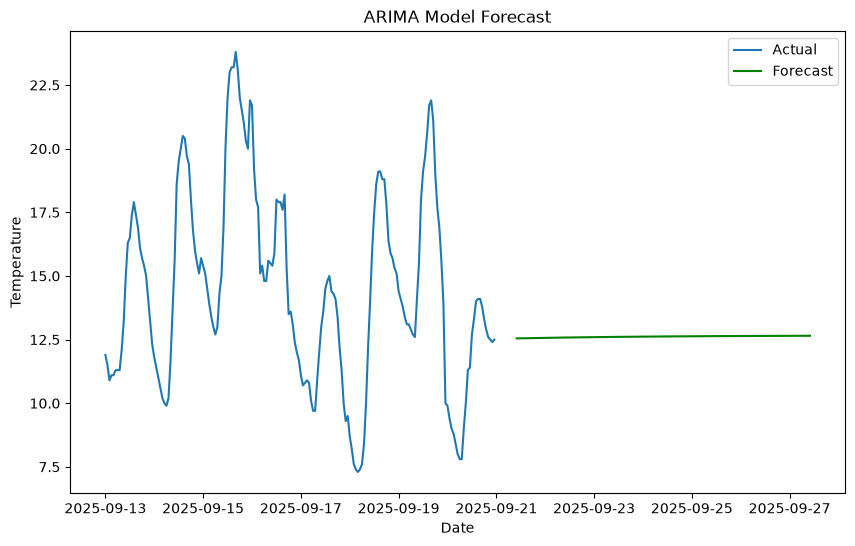

In [22]:
# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(wdf['Temp'], label='Actual')
plt.plot(forecast_index, forecast, label='Forecast', color='green')
plt.title('ARIMA Model Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()